**Imports**

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [43]:
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [44]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [45]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

criterion = nn.CrossEntropyLoss()

In [46]:
train_losses = []
train_accuracies = []
val_losses = []

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):

    model.train()

    correct, total, loss_sum = 0, 0, 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

    epoch_loss = loss_sum / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()

    val_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_losses.append(val_loss / len(test_loader))

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Acc: {epoch_acc:.2f}%"
    )

Epoch 1 | Loss: 0.6193 | Acc: 77.91%
Epoch 2 | Loss: 0.4282 | Acc: 84.58%
Epoch 3 | Loss: 0.3921 | Acc: 85.58%
Epoch 4 | Loss: 0.3731 | Acc: 86.22%
Epoch 5 | Loss: 0.3600 | Acc: 86.87%
Epoch 6 | Loss: 0.3460 | Acc: 87.34%
Epoch 7 | Loss: 0.3366 | Acc: 87.53%
Epoch 8 | Loss: 0.3251 | Acc: 87.88%
Epoch 9 | Loss: 0.3216 | Acc: 88.08%
Epoch 10 | Loss: 0.3139 | Acc: 88.31%


In [47]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
avg_loss = test_loss / len(test_loader)

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Loss: {avg_loss:.4f}")

Test Accuracy: 88.01%
Test Loss: 0.3340


In [48]:
model2 = MLP()

criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

num_epochs = 10

for epoch in range(num_epochs):

    model2.train()

    correct, total, loss_sum = 0, 0, 0

    for images, labels in train_loader:

        optimizer2.zero_grad()

        outputs = model2(images)
        loss = criterion2(outputs, labels)

        loss.backward()
        optimizer2.step()

        loss_sum += loss.item()

        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    print(
        f"Exp2 Epoch {epoch+1} | "
        f"Loss: {loss_sum/len(train_loader):.4f} | "
        f"Acc: {100*correct/total:.2f}%"
    )

Exp2 Epoch 1 | Loss: 0.6382 | Acc: 76.44%
Exp2 Epoch 2 | Loss: 0.5412 | Acc: 80.35%
Exp2 Epoch 3 | Loss: 0.5092 | Acc: 81.50%
Exp2 Epoch 4 | Loss: 0.5012 | Acc: 81.77%
Exp2 Epoch 5 | Loss: 0.4850 | Acc: 82.60%
Exp2 Epoch 6 | Loss: 0.4759 | Acc: 82.96%
Exp2 Epoch 7 | Loss: 0.4688 | Acc: 83.20%
Exp2 Epoch 8 | Loss: 0.4590 | Acc: 83.63%
Exp2 Epoch 9 | Loss: 0.4547 | Acc: 83.66%
Exp2 Epoch 10 | Loss: 0.4546 | Acc: 83.77%


In [49]:
model2.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model2(images)
        loss = criterion2(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
avg_loss = test_loss / len(test_loader)

print("Model 2 Results:")
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Loss: {avg_loss:.4f}")

Model 2 Results:
Test Accuracy: 85.02%
Test Loss: 0.4402


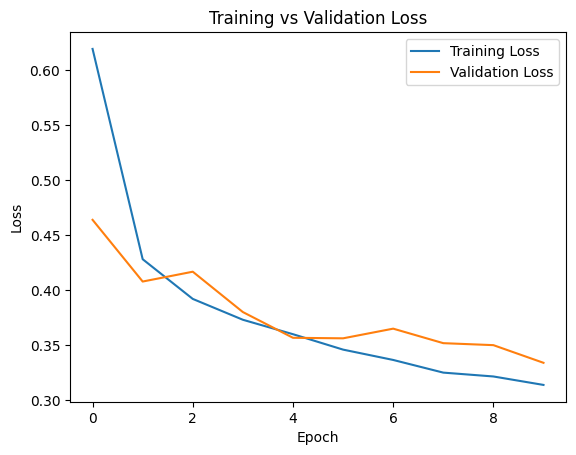

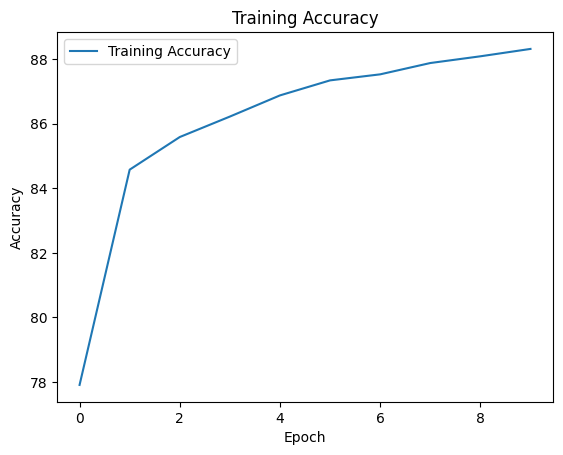

In [50]:

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

plt.plot(train_accuracies, label="Training Accuracy")

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()